# Figures 3 & 4 — training convergence curves

- **Figure 3:** shallow CNN on **preprocessed** PCam and CAMELYON17 (`experiments/cnn_baseline_*/pcam_preprocessed|cam17_preprocessed/metrics_per_epoch.json`). **Newer training logs** include `val_loss` and `val_accuracy` (BCE-with-logits mean and accuracy at threshold 0.5). **Older logs** only have `val_roc_auc_raw_sigmoid`; the notebook then uses three rows (train loss, train acc, val ROC-AUC). Re-run `scripts/cnn_baseline_full_pipeline.py` (or your Colab wrapper) after updating the script to refresh the JSON.
- **Figure 4:** Virchow2 (frozen encoder + linear head) — **train/validation loss and accuracy** per epoch (`metrics_history.json` in each run folder).

Outputs (300 dpi): `reports/figures/figure3_cnn_training_curves.{png,pdf}` and `figure4_virchow_training_curves.{png,pdf}`.

Default Virchow paths point at `experiments/virchow_colab/` if present; override `VIRCHOW_*_RUN` if your runs live elsewhere.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_cwd = Path.cwd().resolve()
REPO = _cwd if (_cwd / "experiments").is_dir() else _cwd.parent
if not (REPO / "experiments").is_dir():
    REPO = Path(r"C:\GP_ECG")

FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CNN_RUN = REPO / "experiments" / "cnn_baseline_20260512_160329"
CNN_PCAM = CNN_RUN / "pcam_preprocessed" / "metrics_per_epoch.json"
CNN_CAM17 = CNN_RUN / "cam17_preprocessed" / "metrics_per_epoch.json"

# Virchow: folder containing metrics_history.json (one run per training corpus). Defaults match repo layout.
_default_virchow = REPO / "experiments" / "virchow_colab"
VIRCHOW_PCAM_RUN = _default_virchow / "virchow_macenko_bench_run_01"
VIRCHOW_CAM17_RUN = _default_virchow / "virchow_wilds_preprocessed_run_01"

DPI = 300
COLORS = {"PCam": "#1f77b4", "CAMELYON17": "#d62728"}

FIG3_PNG = FIG_DIR / "figure3_cnn_training_curves.png"
FIG3_PDF = FIG_DIR / "figure3_cnn_training_curves.pdf"
FIG4_PNG = FIG_DIR / "figure4_virchow_training_curves.png"
FIG4_PDF = FIG_DIR / "figure4_virchow_training_curves.pdf"

print("REPO:", REPO)
print("CNN PCam:", CNN_PCAM, "exists:", CNN_PCAM.is_file())
print("CNN CAM17:", CNN_CAM17, "exists:", CNN_CAM17.is_file())
print("Virchow PCam run:", VIRCHOW_PCAM_RUN, "metrics_history:", (VIRCHOW_PCAM_RUN / "metrics_history.json").is_file())
print("Virchow CAM17 run:", VIRCHOW_CAM17_RUN, "metrics_history:", (VIRCHOW_CAM17_RUN / "metrics_history.json").is_file())

REPO: C:\GP_ECG
CNN PCam: C:\GP_ECG\experiments\cnn_baseline_20260512_160329\pcam_preprocessed\metrics_per_epoch.json exists: True
CNN CAM17: C:\GP_ECG\experiments\cnn_baseline_20260512_160329\cam17_preprocessed\metrics_per_epoch.json exists: True
Virchow PCam run: C:\GP_ECG\experiments\virchow_colab\virchow_macenko_bench_run_01 metrics_history: True
Virchow CAM17 run: C:\GP_ECG\experiments\virchow_colab\virchow_wilds_preprocessed_run_01 metrics_history: True


In [2]:
def load_json(path: Path) -> list | dict:
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def series(history: list, key: str) -> tuple[np.ndarray, np.ndarray]:
    epochs = np.array([int(r["epoch"]) for r in history], dtype=int)
    vals = np.array([float(r[key]) for r in history], dtype=float)
    return epochs, vals


def plot_pair(ax, hist_pcam: list, hist_cam: list, key: str, ylabel: str, title: str):
    for hist, label in ((hist_pcam, "PCam"), (hist_cam, "CAMELYON17")):
        ep, y = series(hist, key)
        ax.plot(ep, y, "o-", label=label, color=COLORS[label], linewidth=1.8, markersize=4)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)


cnn_pcam = load_json(CNN_PCAM)
cnn_cam = load_json(CNN_CAM17)
print(f"CNN epochs: PCam {len(cnn_pcam)}, CAM17 {len(cnn_cam)}")

CNN epochs: PCam 10, CAM17 10


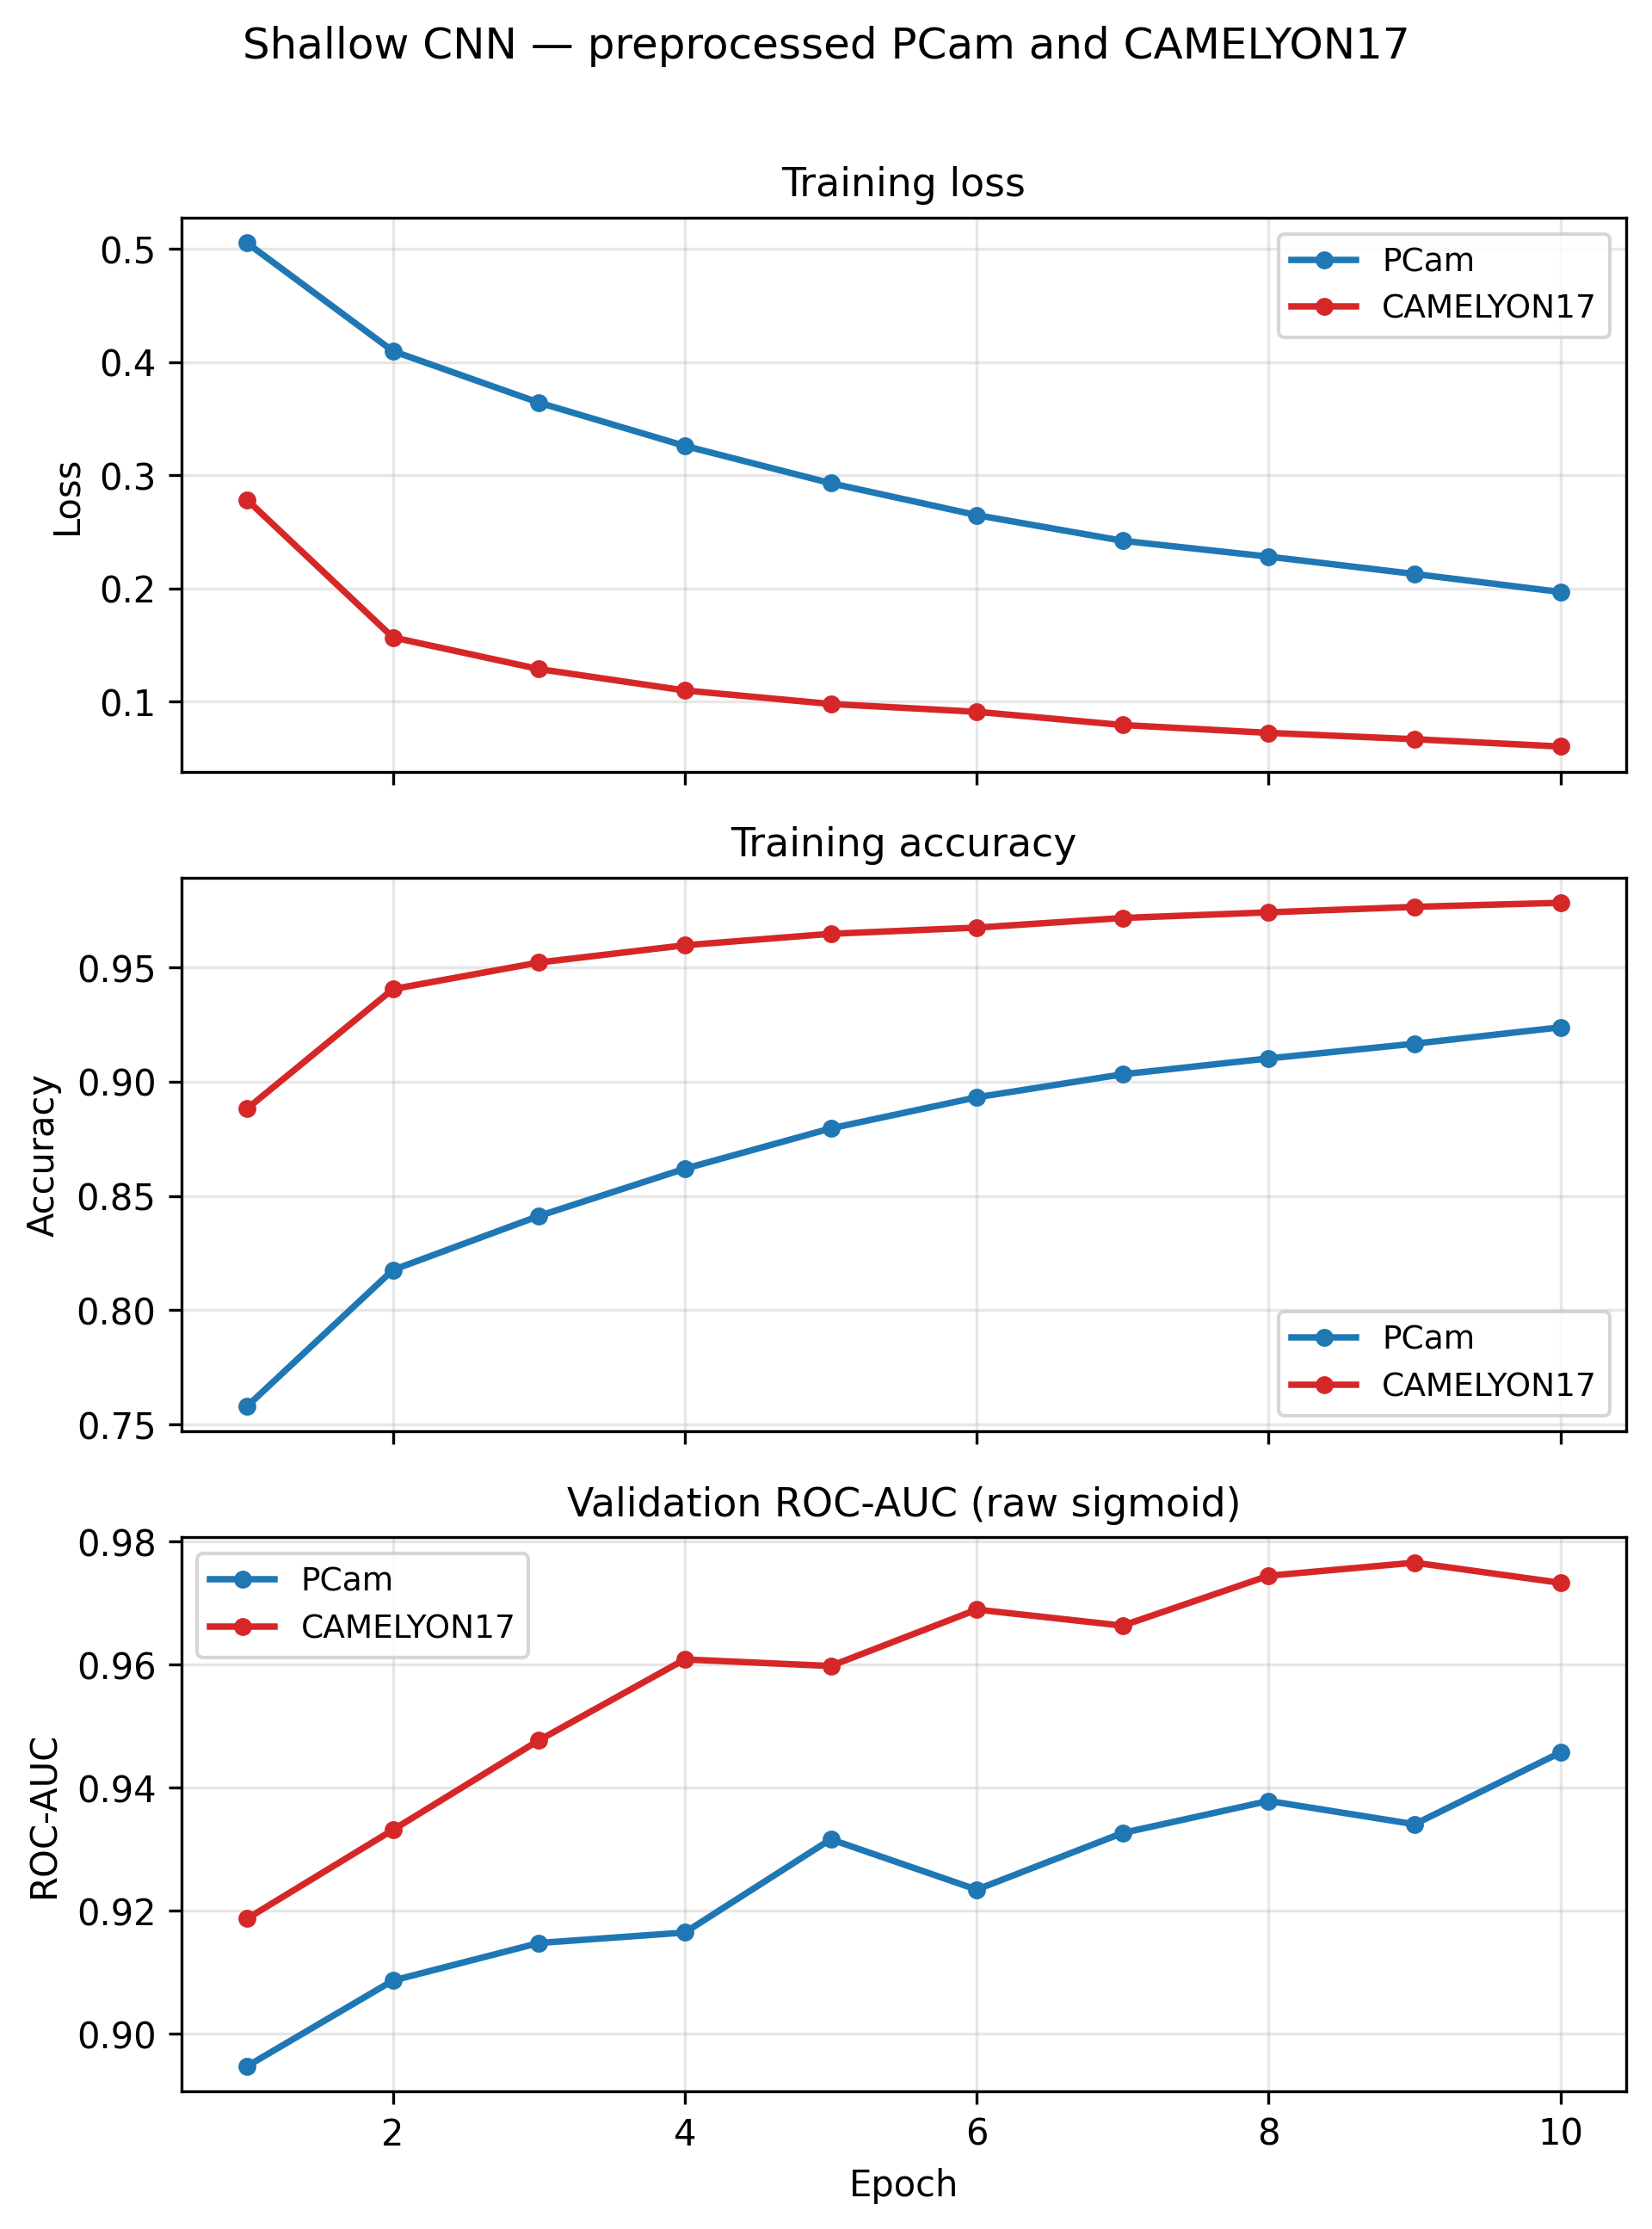

Saved: C:\GP_ECG\reports\figures\figure3_cnn_training_curves.png


In [3]:
has_val_extra = (
    cnn_pcam
    and isinstance(cnn_pcam[0], dict)
    and "val_loss" in cnn_pcam[0]
    and "val_accuracy" in cnn_pcam[0]
)

if has_val_extra:
    fig, axes = plt.subplots(2, 2, figsize=(9, 7), dpi=DPI)
    plot_pair(axes[0, 0], cnn_pcam, cnn_cam, "train_loss", "Loss", "Training loss")
    plot_pair(axes[0, 1], cnn_pcam, cnn_cam, "val_loss", "Loss", "Validation loss")
    plot_pair(axes[1, 0], cnn_pcam, cnn_cam, "train_accuracy", "Accuracy", "Training accuracy")
    plot_pair(axes[1, 1], cnn_pcam, cnn_cam, "val_accuracy", "Accuracy", "Validation accuracy")
    for ax in axes[1, :]:
        ax.set_xlabel("Epoch")
    fig.suptitle("Shallow CNN — preprocessed PCam and CAMELYON17", fontsize=12, y=1.02)
else:
    fig, axes = plt.subplots(3, 1, figsize=(6.5, 8.5), sharex=True, dpi=DPI)
    plot_pair(axes[0], cnn_pcam, cnn_cam, "train_loss", "Loss", "Training loss")
    plot_pair(axes[1], cnn_pcam, cnn_cam, "train_accuracy", "Accuracy", "Training accuracy")
    plot_pair(axes[2], cnn_pcam, cnn_cam, "val_roc_auc_raw_sigmoid", "ROC-AUC", "Validation ROC-AUC (raw sigmoid; only metric in older logs)")
    axes[2].set_xlabel("Epoch")
    fig.suptitle("Shallow CNN — preprocessed PCam and CAMELYON17", fontsize=12, y=1.01)

fig.tight_layout()
fig.savefig(FIG3_PNG, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(FIG3_PDF, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIG3_PNG)

In [4]:
def resolve_virchow_run(path: Path, name: str) -> Path:
    hist = path / "metrics_history.json"
    if hist.is_file():
        return hist
    raise FileNotFoundError(
        f"Missing {hist}. Set {name} in the config cell "
        "(or copy metrics_history.json from Colab into that folder)."
    )


virchow_pcam_hist = load_json(resolve_virchow_run(VIRCHOW_PCAM_RUN, "VIRCHOW_PCAM_RUN"))
virchow_cam_hist = load_json(resolve_virchow_run(VIRCHOW_CAM17_RUN, "VIRCHOW_CAM17_RUN"))

for tag, h in ("PCam", virchow_pcam_hist), ("CAM17", virchow_cam_hist):
    keys = set(h[0].keys()) if h else set()
    need = {"train_loss", "train_acc", "val_loss", "val_acc"}
    if not need.issubset(keys):
        print(f"WARNING {tag}: expected keys {need}, got {keys}")

print(f"Virchow epochs: PCam {len(virchow_pcam_hist)}, CAM17 {len(virchow_cam_hist)}")

Virchow epochs: PCam 10, CAM17 10


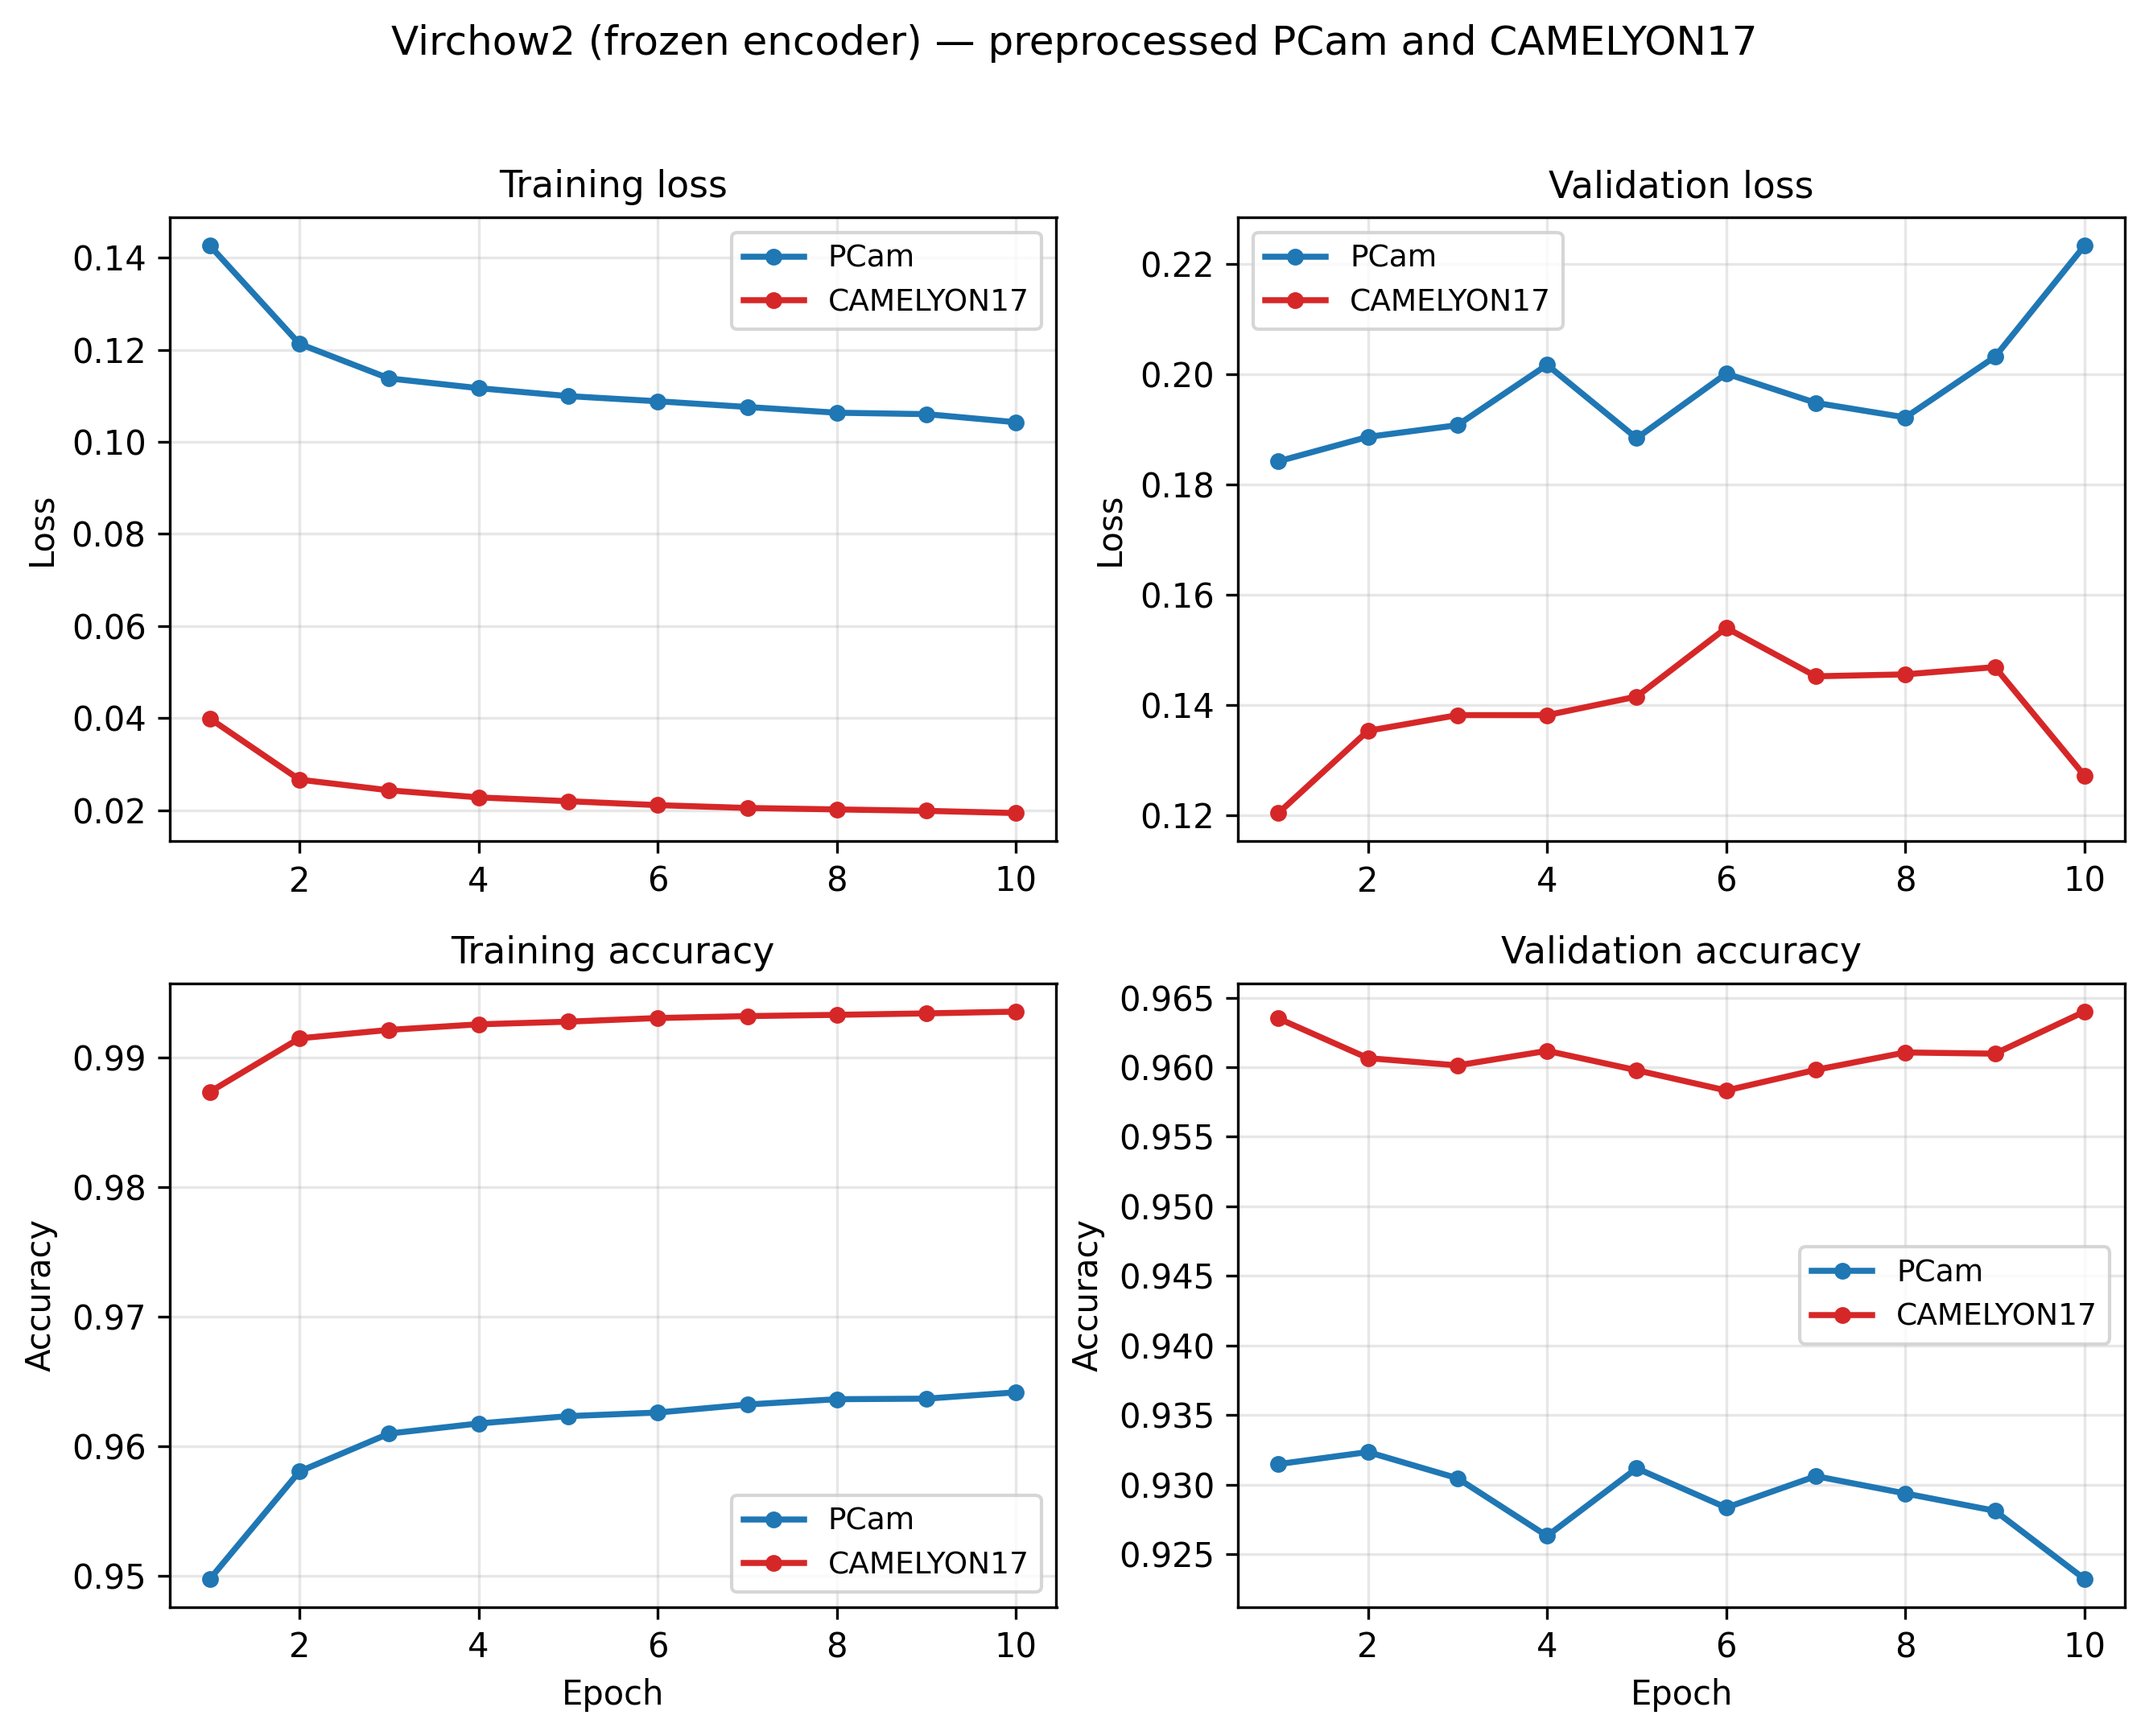

Saved: C:\GP_ECG\reports\figures\figure4_virchow_training_curves.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), dpi=DPI)
plot_pair(axes[0, 0], virchow_pcam_hist, virchow_cam_hist, "train_loss", "Loss", "Training loss")
plot_pair(axes[0, 1], virchow_pcam_hist, virchow_cam_hist, "val_loss", "Loss", "Validation loss")
plot_pair(axes[1, 0], virchow_pcam_hist, virchow_cam_hist, "train_acc", "Accuracy", "Training accuracy")
plot_pair(axes[1, 1], virchow_pcam_hist, virchow_cam_hist, "val_acc", "Accuracy", "Validation accuracy")
for ax in axes[1, :]:
    ax.set_xlabel("Epoch")
for ax in axes[:, 0]:
    pass
fig.suptitle("Virchow2 (frozen encoder) — preprocessed PCam and CAMELYON17", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIG4_PNG, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(FIG4_PDF, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIG4_PNG)

### Optional: copy `metrics_history.json` from Drive into the repo

If your Virchow runs live on Google Drive, copy each run folder (or at least `metrics_history.json`) under e.g. `experiments/virchow_pcam_preprocessed/` and set `VIRCHOW_PCAM_RUN` / `VIRCHOW_CAM17_RUN` accordingly, then re-run the Virchow cells.